# 03 — Positivity Violation and Unstable Weights

**Goal.** This notebook illustrates why the **positivity assumption** is essential in causal inference.

The positivity assumption means:

$$
0 < P(A=1 \mid X=x) < 1
$$

for all covariate values where we want to estimate a causal effect.

If positivity is violated, some individuals have almost no chance of receiving one of the treatments. In that case, causal comparisons require extrapolation and IPW weights can become very large.

## What this notebook shows

1. A moderate-overlap scenario;
2. A poor-overlap scenario;
3. Large IPW weights under near-positivity violation;
4. Weight truncation and trimming as practical diagnostics.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, LogisticRegression

FIG_DIR = Path("figures")
RES_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def summarize_estimates(estimates, true_ate):
    return pd.DataFrame([
        {
            "Estimator": name,
            "Estimate": value,
            "True ATE": true_ate,
            "Bias": value - true_ate,
            "Absolute error": abs(value - true_ate),
        }
        for name, value in estimates.items()
    ])

## 1. Simulation function

The parameter `treatment_slope` controls how deterministic the treatment assignment becomes.

- Small or moderate slope: better overlap;
- Large slope: poor overlap and near-positivity violation.

In [11]:
def simulate_data(n=5000, tau=2.0, beta0=1.0, gamma=1.5,
                  treatment_intercept=-0.2, treatment_slope=1.3,
                  noise_sd=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, n)
    p_treat = sigmoid(treatment_intercept + treatment_slope * X)
    A = rng.binomial(1, p_treat, n)
    eps = rng.normal(0, noise_sd, n)
    Y = beta0 + tau * A + gamma * X + eps
    return pd.DataFrame({"X": X, "A": A, "Y": Y, "true_propensity": p_treat})

def estimate_ps(df):
    model = LogisticRegression(solver="lbfgs")
    model.fit(df[["X"]], df["A"])
    df = df.copy()
    df["estimated_propensity"] = model.predict_proba(df[["X"]])[:, 1]
    return df, model

def compute_ipw_weights(df, ps_col="estimated_propensity"):
    e = np.clip(df[ps_col].to_numpy(), 1e-6, 1 - 1e-6)
    A = df["A"].to_numpy()
    return A / e + (1 - A) / (1 - e)

def ipw_hajek_ate(df, ps_col="estimated_propensity"):
    A = df["A"].to_numpy()
    Y = df["Y"].to_numpy()
    e = np.clip(df[ps_col].to_numpy(), 1e-6, 1 - 1e-6)
    mu1 = np.sum(A * Y / e) / np.sum(A / e)
    mu0 = np.sum((1 - A) * Y / (1 - e)) / np.sum((1 - A) / (1 - e))
    return mu1 - mu0

def effective_sample_size(weights):
    weights = np.asarray(weights)
    return weights.sum() ** 2 / np.sum(weights ** 2)

TRUE_ATE = 2.0

## 2. Generate two scenarios

In [12]:
df_good = simulate_data(treatment_slope=1.2, seed=42)
df_poor = simulate_data(treatment_slope=4.0, seed=42)
df_good, _ = estimate_ps(df_good)
df_poor, _ = estimate_ps(df_poor)
df_good["ipw_weight"] = compute_ipw_weights(df_good)
df_poor["ipw_weight"] = compute_ipw_weights(df_poor)

summary_overlap = pd.DataFrame({
    "Scenario": ["Moderate overlap", "Poor overlap"],
    "Min estimated PS": [df_good["estimated_propensity"].min(), df_poor["estimated_propensity"].min()],
    "Max estimated PS": [df_good["estimated_propensity"].max(), df_poor["estimated_propensity"].max()],
    "Mean IPW weight": [df_good["ipw_weight"].mean(), df_poor["ipw_weight"].mean()],
    "Max IPW weight": [df_good["ipw_weight"].max(), df_poor["ipw_weight"].max()],
    "Effective sample size": [effective_sample_size(df_good["ipw_weight"]), effective_sample_size(df_poor["ipw_weight"])],
})
summary_overlap

,Scenario,Min estimated PS,Max estimated PS,Mean IPW weight,Max IPW weight,Effective sample size
0,Moderate overlap,1.112364e-02,0.978784,1.988751,30.067047,3437.946562
1,Poor overlap,4.695815e-07,0.999999,2.221762,1420.168949,51.280795


## 3. Visualize overlap

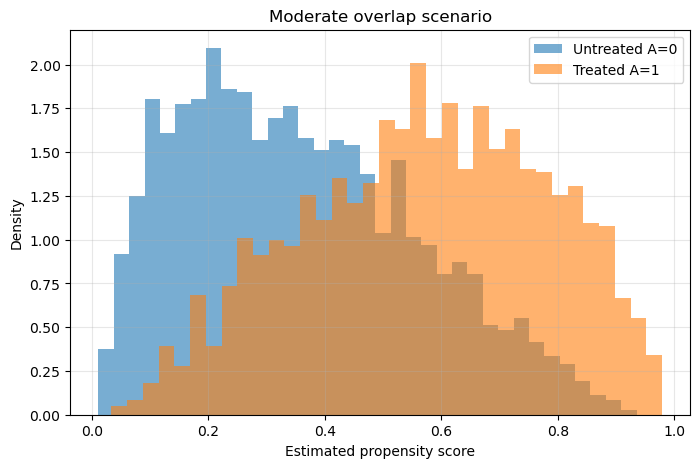

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df_good.loc[df_good["A"] == 0, "estimated_propensity"], bins=35, alpha=0.6, label="Untreated A=0", density=True)
plt.hist(df_good.loc[df_good["A"] == 1, "estimated_propensity"], bins=35, alpha=0.6, label="Treated A=1", density=True)
plt.xlabel("Estimated propensity score")
plt.ylabel("Density")
plt.title("Moderate overlap scenario")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "03_moderate_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

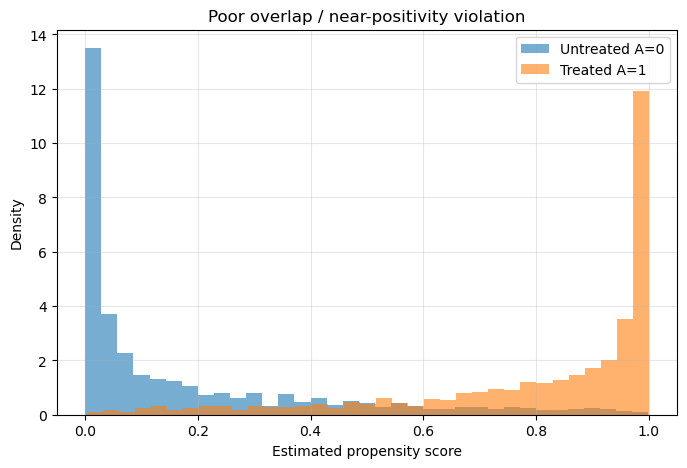

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df_poor.loc[df_poor["A"] == 0, "estimated_propensity"], bins=35, alpha=0.6, label="Untreated A=0", density=True)
plt.hist(df_poor.loc[df_poor["A"] == 1, "estimated_propensity"], bins=35, alpha=0.6, label="Treated A=1", density=True)
plt.xlabel("Estimated propensity score")
plt.ylabel("Density")
plt.title("Poor overlap / near-positivity violation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "03_poor_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Visualize weight instability

When estimated propensity scores are close to 0 or 1, IPW weights can become very large.

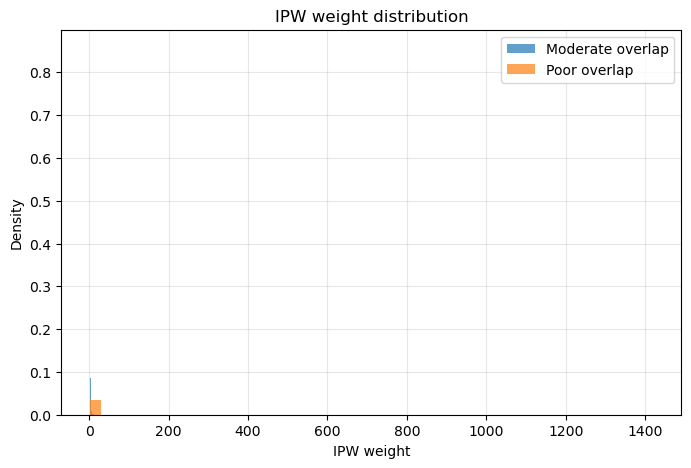

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_good["ipw_weight"], bins=50, alpha=0.7, label="Moderate overlap", density=True)
plt.hist(df_poor["ipw_weight"], bins=50, alpha=0.7, label="Poor overlap", density=True)
plt.xlabel("IPW weight")
plt.ylabel("Density")
plt.title("IPW weight distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "03_weight_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
weight_quantiles = pd.DataFrame({
    "Quantile": [0.50, 0.75, 0.90, 0.95, 0.99, 1.00],
    "Moderate overlap": np.quantile(df_good["ipw_weight"], [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]),
    "Poor overlap": np.quantile(df_poor["ipw_weight"], [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]),
})
weight_quantiles

,Quantile,Moderate overlap,Poor overlap
0,0.50,1.596032,1.075712
1,0.75,2.160500,1.392188
2,0.90,3.179888,2.326815
3,0.95,4.160303,4.049742
4,0.99,7.421009,14.172499
5,1.00,30.067047,1420.168949


## 5. Effect estimation under poor overlap

In [17]:
def naive_regression_ate(df):
    return LinearRegression().fit(df[["A"]], df["Y"]).coef_[0]

def adjusted_regression_ate(df):
    return LinearRegression().fit(df[["A", "X"]], df["Y"]).coef_[0]

def trimmed_sample(df, lower=0.05, upper=0.95):
    return df[(df["estimated_propensity"] >= lower) & (df["estimated_propensity"] <= upper)].copy()

def truncated_weights_ipw_hajek(df, max_weight=20):
    e = np.clip(df["estimated_propensity"].to_numpy(), 1e-6, 1 - 1e-6)
    A = df["A"].to_numpy()
    Y = df["Y"].to_numpy()
    w1 = np.minimum(A / e, max_weight)
    w0 = np.minimum((1 - A) / (1 - e), max_weight)
    return np.sum(w1 * Y) / np.sum(w1) - np.sum(w0 * Y) / np.sum(w0)

df_poor_trimmed = trimmed_sample(df_poor, lower=0.05, upper=0.95)

estimates = {
    "Naive regression Y~A": naive_regression_ate(df_poor),
    "Adjusted regression Y~A+X": adjusted_regression_ate(df_poor),
    "IPW Hajek": ipw_hajek_ate(df_poor),
    "IPW Hajek + weight truncation": truncated_weights_ipw_hajek(df_poor, max_weight=20),
    "IPW Hajek + trimming": ipw_hajek_ate(df_poor_trimmed),
}
summary = summarize_estimates(estimates, TRUE_ATE)
summary

,Estimator,Estimate,True ATE,Bias,Absolute error
0,Naive regression Y~A,4.150760,2.0,2.150760,2.150760
1,Adjusted regression Y~A+X,1.954902,2.0,-0.045098,0.045098
2,IPW Hajek,1.883205,2.0,-0.116795,0.116795
3,IPW Hajek + weight truncation,2.866093,2.0,0.866093,0.866093
4,IPW Hajek + trimming,1.960059,2.0,-0.039941,0.039941


Original sample size: 5000
Trimmed sample size: 2768
Percentage removed by trimming: 44.64%


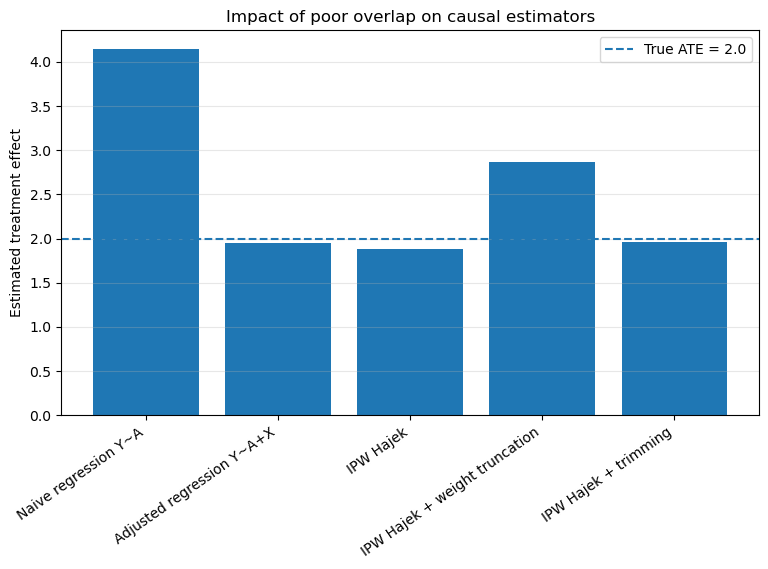

In [18]:
print(f"Original sample size: {len(df_poor)}")
print(f"Trimmed sample size: {len(df_poor_trimmed)}")
print(f"Percentage removed by trimming: {(1 - len(df_poor_trimmed) / len(df_poor)) * 100:.2f}%")

plt.figure(figsize=(9, 5))
plt.bar(summary["Estimator"], summary["Estimate"])
plt.axhline(TRUE_ATE, linestyle="--", label=f"True ATE = {TRUE_ATE}")
plt.ylabel("Estimated treatment effect")
plt.title("Impact of poor overlap on causal estimators")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(FIG_DIR / "03_positivity_estimator_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Interpretation

Poor overlap means that the data do not contain enough comparable treated and untreated individuals across all covariate regions. IPW then gives very large weights to a small number of observations, which can make estimates unstable.

Trimming and weight truncation are practical diagnostics and sensitivity tools, but they do not fully solve the scientific problem. They usually change the target population or introduce bias-variance trade-offs.

## Key message

The positivity assumption is not only a technical condition. It is a practical requirement for reliable causal learning from observational data.